# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:34.341


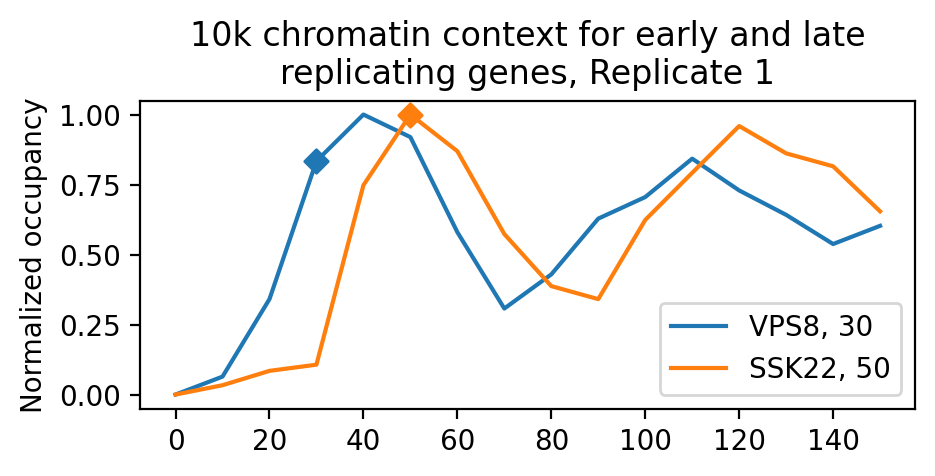

In [4]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

(16, 1)

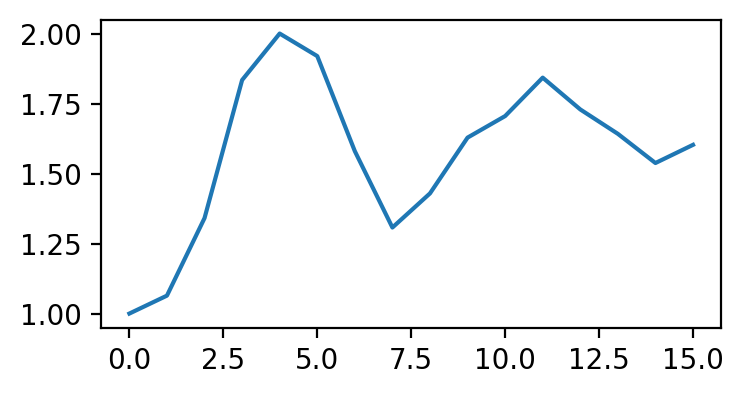

In [29]:
from src.sgd import get_orfname

orfname = get_orfname('VPS8')
g = mnase_analysis_rep1.normalized_bin_curves.loc[orfname].values.reshape((-1, 1))+1.
plt.figure(figsize=(4, 2))
plt.plot(g[:, 0])
g.shape

In [30]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.helpers import calcH

config = create_dynamic_alpha_config(replicate=1, alpha=14)

H, Hpos = calcH(config.intervals_wt1, config.WT1_TIMEPOINTS)


In [31]:
# Create a class that allows us to handle smoothing of the G1s and G2M (subset of PostG1)
# what will the result look like?
# Will require padding code, what will S look like?

# Let's start with baseline:
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

solver = ReplicationChromatinDeconvolveSolver(config, H, g, (1, 1))

In [32]:
solver.define_deconvolution_problem()

In [33]:
f, rn, sn, _ = solver.solve(gamma_value=0.001)

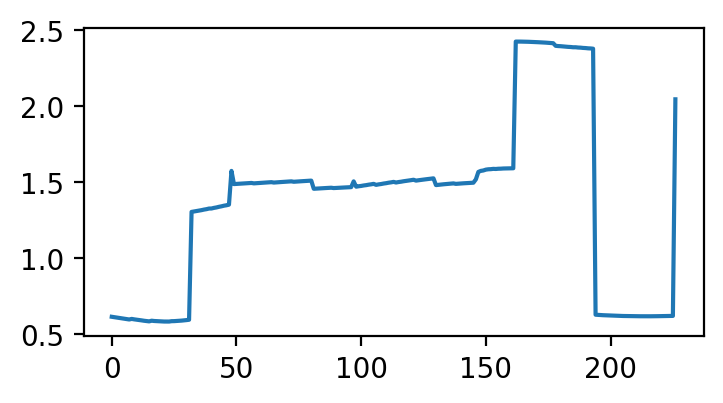

In [34]:
plt.figure(figsize=(4, 2))
plt.plot(f)

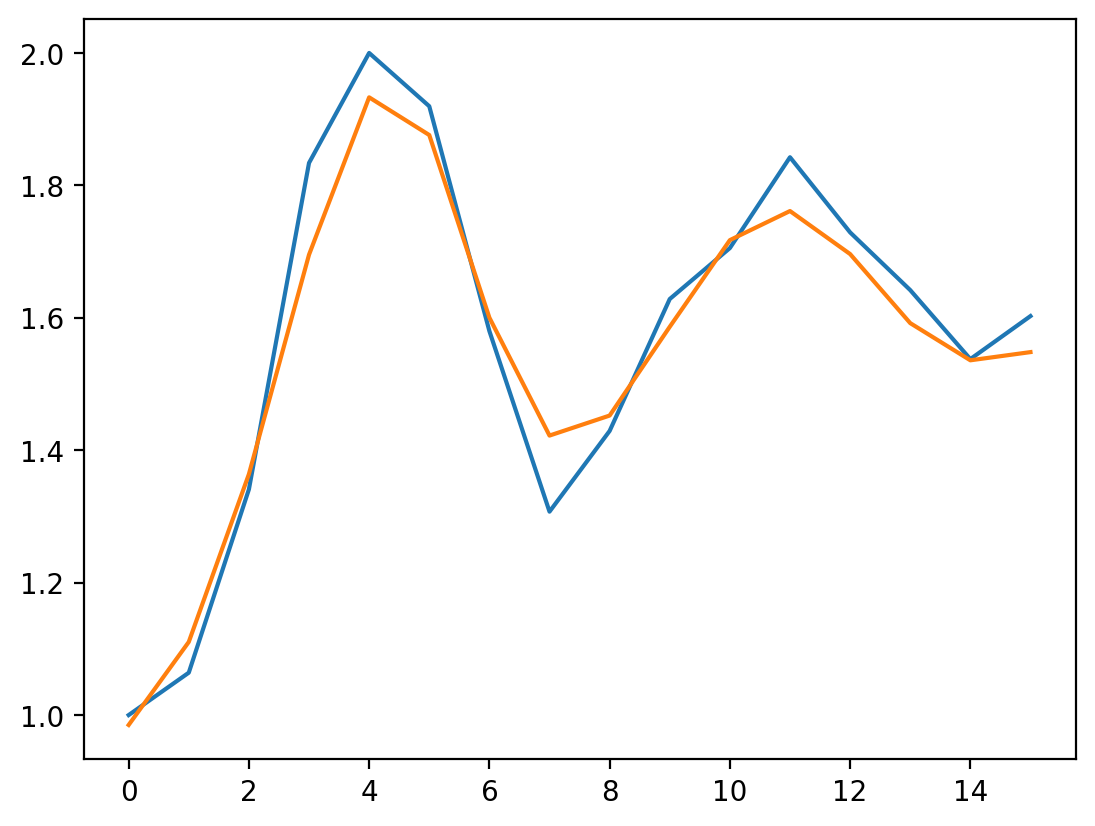

In [35]:
plt.plot(g)
plt.plot(H@f)